# Student Risk Prediction — Machine Learning Module (NoorLearn)

### Project objective
Build a classification model that predicts whether a student is **at risk of failing** (`Risk = 1`) or **not at risk** (`Risk = 0`), using the UCI Student Performance dataset. This model powers the "AI Risk Predictor" feature inside NoorLearn's Performance Analytics module.

### Complete workflow
1. Import libraries
2. Load dataset
3. Understand the dataset
4. Check data quality
5. Exploratory Data Analysis (EDA)
6. Create the target variable (Risk)
7. Encode categorical features
8. Separate features and target
9. Train-test split
10. Feature scaling
11. Train multiple models
12. Compare models
13. Confusion matrix + feature importance
14. Select final model
15. Predict a new student
16. Save the trained model for Flask to use

## Step 1 — Import libraries

We will use:
- **Pandas** for data handling
- **NumPy** for numerical operations
- **Matplotlib / Seaborn** for visualization
- **Scikit-learn** for machine learning
- **Joblib** to save the trained model and scaler (Flask will load these later)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Step 2 — Load the dataset

**Download first:** Go to the UCI Machine Learning Repository or Kaggle and search "Student Performance Data Set" (by Paulo Cortez). Download `student-mat.csv` (Math course results) and place it in the **same folder** as this notebook.

This dataset uses a semicolon `;` as the separator, not a comma — note the `sep=";"` below.

In [9]:
# Load dataset
df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (395, 33)


## Step 3 — View the first records

`head()` helps us understand the structure and values in the dataset.

In [10]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 4 — Understand rows and columns

- `shape` → number of rows and columns
- `columns` → column names
- `dtypes` → data types

In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data Types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2          

## Step 5 — Check dataset information

`info()` tells us about number of records, data types, and non-null values.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## Step 6 — Statistical summary

`describe()` gives statistics such as mean, standard deviation, minimum, maximum and quartiles.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


## Step 7 — Check missing values

Before training a model, always check whether data is missing.

In [14]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

No missing values found.


## Step 8 — Check duplicate rows

In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Step 9 — Create the target variable: Risk

The raw dataset gives final grades `G1`, `G2`, `G3` (each out of 20), not a ready-made "at risk" label — we define it ourselves, which is a genuine modeling decision (this is a good thing to explain in your pitch: you are not just using a pre-labeled dataset, you are framing the ML problem).

**Definition used here:** a student is `Risk = 1` if their final grade `G3` is below 10 (out of 20, i.e. failing), otherwise `Risk = 0`.

Risk
0    265
1    130
Name: count, dtype: int64


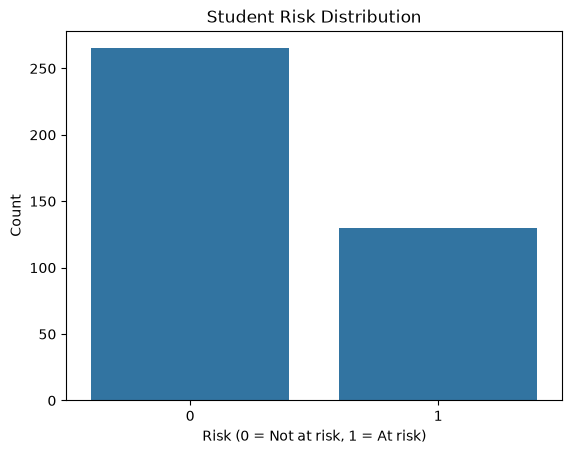

In [16]:
df["Risk"] = (df["G3"] < 10).astype(int)

print(df["Risk"].value_counts())

sns.countplot(x="Risk", data=df)
plt.title("Student Risk Distribution")
plt.xlabel("Risk (0 = Not at risk, 1 = At risk)")
plt.ylabel("Count")
plt.show()

## Step 10 — Drop the grade columns used to build the target

`G1`, `G2`, and `G3` directly determine `Risk`, so if we leave them in as features the model would just be copying the rule we used to create the label instead of learning real early-warning signals. We drop them so the model has to rely on behaviour/context features instead — study time, past failures, absences, family support, etc. This is what makes the prediction genuinely useful **before** final grades exist.

In [17]:
df_model = df.drop(columns=["G1", "G2", "G3"])
print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'Risk']


## Step 11 — Exploratory Data Analysis

Look at how a couple of key features relate to risk.

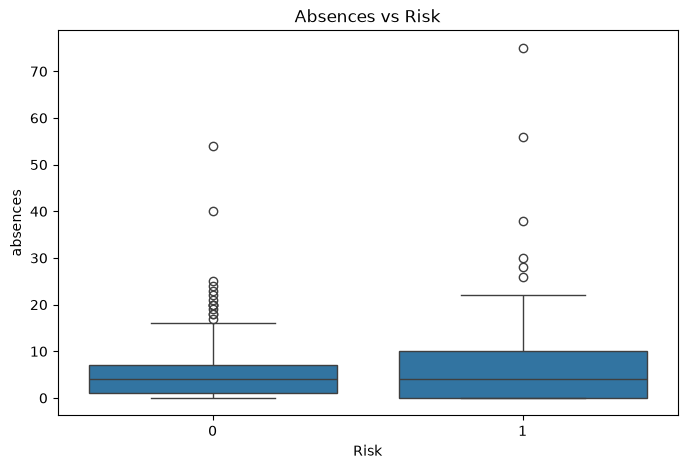

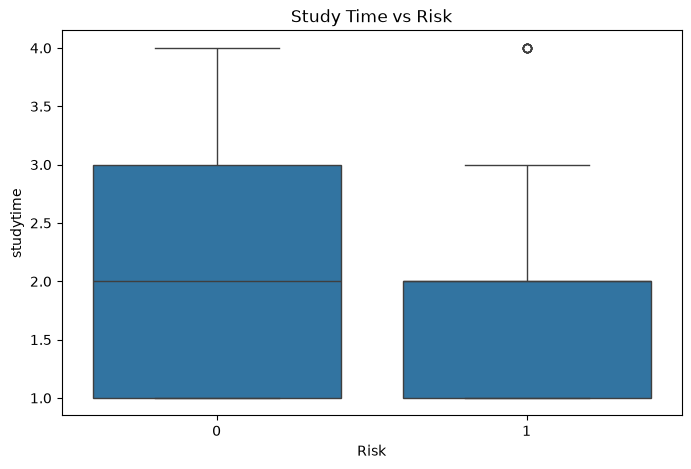

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Risk", y="absences", data=df_model)
plt.title("Absences vs Risk")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="Risk", y="studytime", data=df_model)
plt.title("Study Time vs Risk")
plt.show()

## Step 12 — Encode categorical features

This dataset has many text columns (e.g. `sex`, `school`, `address`, `famsize`, `Mjob`, `Fjob`, `internet`). Machine learning models need numbers, so we convert each categorical column with `LabelEncoder`. We keep a dictionary of encoders so the Flask app can apply the *same* encoding later to new student input.

In [19]:
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

print("Encoding complete.")
df_model.head()

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Encoding complete.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8772\612683903.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include="object").columns.tolist()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Risk
0,0,0,18,1,0,0,4,4,0,4,...,0,0,4,3,4,1,1,3,6,1
1,0,0,17,1,0,1,1,1,0,2,...,1,0,5,3,3,1,1,3,4,1
2,0,0,15,1,1,1,1,1,0,2,...,1,0,4,3,2,2,3,3,10,0
3,0,0,15,1,0,1,4,2,1,3,...,1,1,3,2,2,1,1,5,2,0
4,0,0,16,1,0,1,3,3,2,2,...,0,0,4,3,2,1,2,5,4,0


## Step 13 — Define features (X) and target (y)

In [20]:
X = df_model.drop("Risk", axis=1)
y = df_model["Risk"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 30)
y shape: (395,)


## Step 14 — Train-test split

We use 80% for training and 20% for testing. `stratify=y` keeps the class proportion similar in both sets.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 30)
Testing data: (79, 30)


## Step 15 — Feature scaling

Logistic Regression and KNN benefit from scaling. We use `StandardScaler`, fitting only on training data to avoid leaking test information into training.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Step 16 — Model 1: Logistic Regression

A strong, interpretable baseline for binary classification.

In [23]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression
Accuracy: 0.7088607594936709


## Step 17 — Logistic Regression evaluation

In [24]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.73      0.89      0.80        53
           1       0.60      0.35      0.44        26

    accuracy                           0.71        79
   macro avg       0.67      0.62      0.62        79
weighted avg       0.69      0.71      0.68        79



# Step 18 — Model 2: Decision Tree

In [25]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree
Accuracy: 0.6962025316455697


## Step 19 — Decision Tree evaluation

In [26]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.72      0.89      0.80        53
           1       0.57      0.31      0.40        26

    accuracy                           0.70        79
   macro avg       0.65      0.60      0.60        79
weighted avg       0.67      0.70      0.67        79



# Step 20 — Model 3: Random Forest

Combines many decision trees, usually a stronger baseline than a single tree.

In [27]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest
Accuracy: 0.7215189873417721


## Step 21 — Random Forest evaluation

In [28]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.74      0.91      0.81        53
           1       0.64      0.35      0.45        26

    accuracy                           0.72        79
   macro avg       0.69      0.63      0.63        79
weighted avg       0.71      0.72      0.69        79



# Step 22 — Model 4: K-Nearest Neighbors (KNN)

In [29]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))

KNN
Accuracy: 0.5822784810126582


## Step 23 — Compare all models

For an at-risk prediction problem, **recall matters a lot**: missing a student who is actually at risk (a false negative) is worse than flagging a student who turns out to be fine. Keep this in mind when picking the final model, not just accuracy.

In [30]:
models = {
    "Logistic Regression": log_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred
}

results = []
for name, predictions in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.708861,0.600000,0.346154,0.439024
1,Decision Tree,0.696203,0.571429,0.307692,0.400000
2,Random Forest,0.721519,0.642857,0.346154,0.450000
3,KNN,0.582278,0.347826,0.307692,0.326531


## Step 24 — Visualize model comparison

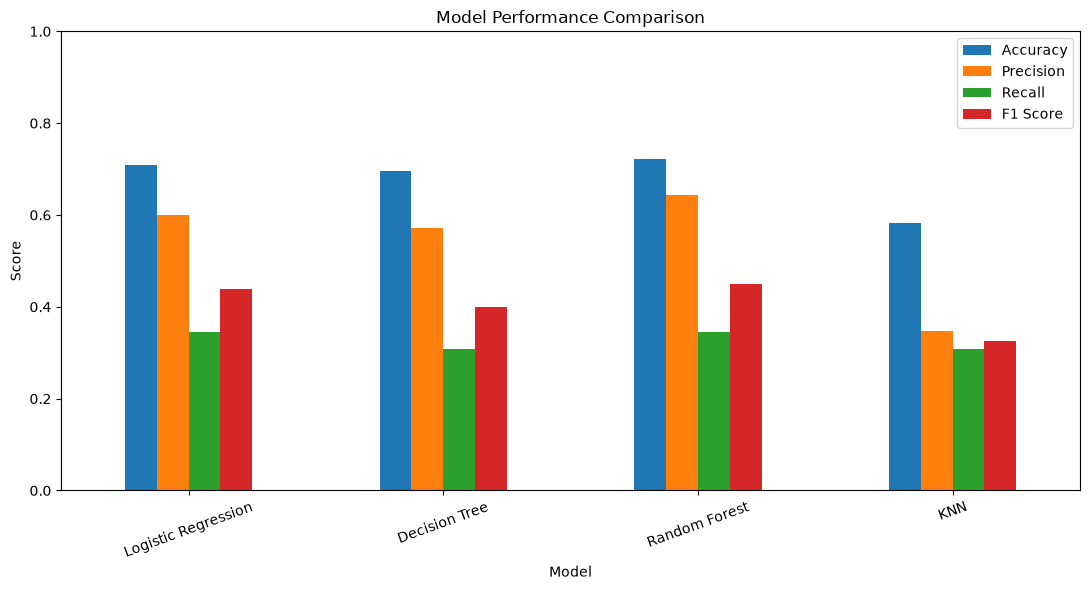

In [31]:
results_plot = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

results_plot.plot(kind="bar", figsize=(11, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Step 25 — Confusion Matrix for Random Forest

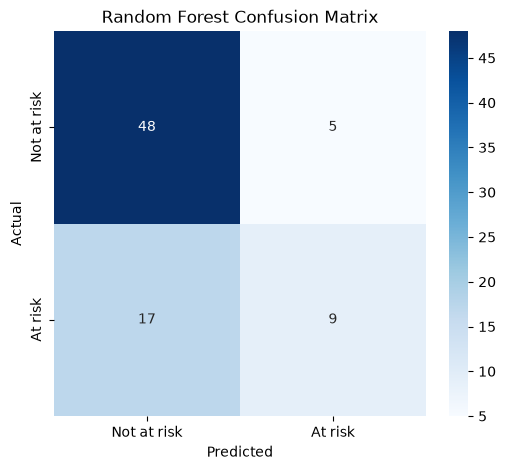

In [32]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not at risk", "At risk"],
    yticklabels=["Not at risk", "At risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Step 26 — Feature importance

This tells you (and your judges) *which factors the model actually relies on* — a great slide/talking point, e.g. "our model found absences and past failures matter more than family background."

In [33]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

absences    0.097782
failures    0.080126
age         0.053864
goout       0.053549
Medu        0.046401
Mjob        0.046084
health      0.045305
famrel      0.043488
freetime    0.042675
Walc        0.042162
dtype: float64


## Step 27 — Plot feature importance

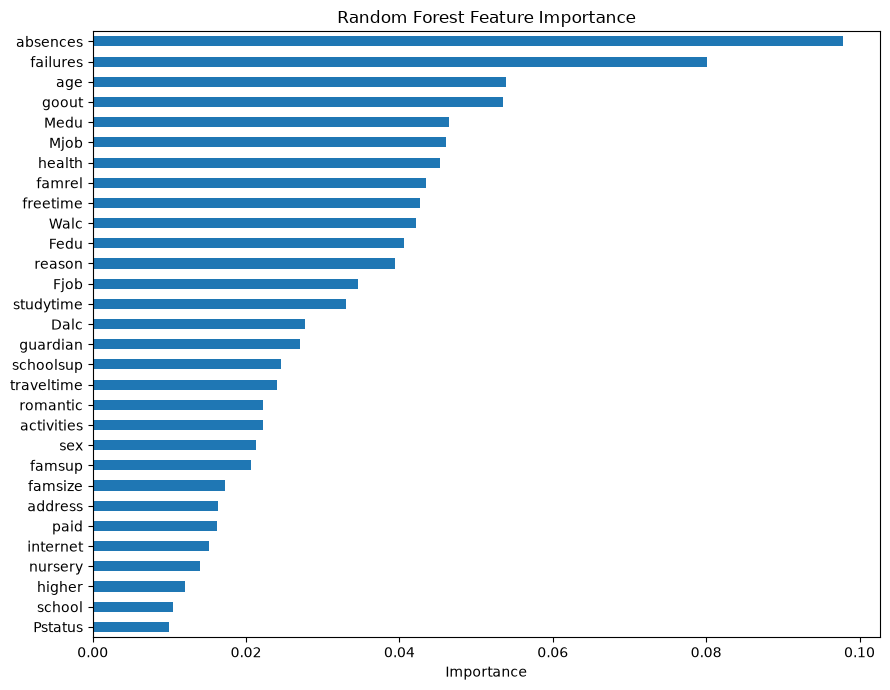

In [34]:
plt.figure(figsize=(9, 7))
feature_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Step 28 — Select the final model

For this project, we use **Random Forest** as the final model, since it does not require scaled input (simpler for the Flask app) and gives us feature importance for explainability. In your pitch, note that in a production setting you'd also run cross-validation and weigh recall more heavily given the cost of missing an at-risk student.

In [35]:
final_model = rf_model
print("Final model selected: Random Forest")

Final model selected: Random Forest


# Step 29 — Predict a new student

The input must have the same columns, in the same order, as `X` — and any categorical column must be encoded using the *same* encoders we fit earlier.

In [36]:
# Example: a student with several risk factors
new_student = X.iloc[[0]].copy()  # start from a real row's structure
new_student.iloc[0] = X.iloc[0]   # placeholder values, replace with real input in the Flask app

prediction = final_model.predict(new_student)[0]
probability = final_model.predict_proba(new_student)[0][1]

print("Prediction:", prediction)
print("Probability of being at risk:", round(probability, 3))
print("Model prediction:", "At risk" if prediction == 1 else "Not at risk")

Prediction: 0
Probability of being at risk: 0.325
Model prediction: Not at risk


# Step 30 — Save the trained model

We save the trained Random Forest model, the scaler, the label encoders (needed to convert new categorical input the same way), and the exact feature column order. Flask will load all four.

In [37]:
joblib.dump(final_model, "risk_model.pkl")
joblib.dump(scaler, "risk_scaler.pkl")
joblib.dump(encoders, "risk_encoders.pkl")
joblib.dump(list(X.columns), "risk_features.pkl")

print("Model saved as: risk_model.pkl")
print("Scaler saved as: risk_scaler.pkl")
print("Encoders saved as: risk_encoders.pkl")
print("Feature list saved as: risk_features.pkl")

Model saved as: risk_model.pkl
Scaler saved as: risk_scaler.pkl
Encoders saved as: risk_encoders.pkl
Feature list saved as: risk_features.pkl


# Step 31 — Verify the saved model

Load it back and confirm it can still make a prediction.

In [38]:
loaded_model = joblib.load("risk_model.pkl")
loaded_features = joblib.load("risk_features.pkl")

loaded_prediction = loaded_model.predict(new_student[loaded_features])[0]
print("Loaded model prediction:", loaded_prediction)

Loaded model prediction: 0
